In [1]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [35]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c':
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v)
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="max")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
        params = gamma.fit(arr)
        posNeg4 = []
        spaceStep4 = np.linspace(0,.99,30)
        for e in spaceStep4:
            #newArr = arr > gamma.ppf(e,alpha,scale=beta)
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2])
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)]

    return tots


def outputResultsArt(X,y,lowerRange=2,upperRange=70,checkValue=1):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v)
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="max")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
        means = np.mean(arr)
        inMean = 1 / means
        alpha = pow(np.mean(arr),2) / np.var(arr)
        beta = np.var(arr) / np.mean(arr)
        params = gamma.fit(arr)
        posNeg4 = []
        spaceStep4 = np.linspace(.9,.99,20)
        for e in spaceStep4:
            #newArr = arr > gamma.ppf(e,alpha,scale=beta)
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2])
            posNeg4.append([((y[newArr] == checkValue).sum() / (y == checkValue).sum()), (y[newArr] != checkValue).sum()/ ((y != checkValue).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="max")
    params = gamma.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    fig, ax = plt.subplots(2,1)
    results = probplot(arr,dist=stats.gamma, plot=ax[0],sparams=(params[0],params[1],params[2]),rvalue=True)
    fig.suptitle(name)
    dista = plt.hist(arr,bins=int(np.sqrt(len(arr))),density=True)
    sns.kdeplot(arr,bw=.3)
    plt.xlabel("Maximum Manhattan Distance")
    plt.ylabel("Density")
    plt.show()

0.7610814897342033 41 [0.7430168709215342, 0.7508455355721788, 0.748716775425752, 0.7480701893999682, 0.7532229826515996, 0.7527753461722108, 0.7558192742320546, 0.7563166480980423, 0.7571223937609421, 0.7551030558650326, 0.7542674677701734, 0.7552522680248288, 0.7562370682794842, 0.7573611332166161, 0.7525763966258158, 0.7452351583638389, 0.7440613560401084, 0.7573511857392965, 0.7564758077351583, 0.7558491166640139, 0.7573511857392964, 0.7579878242877607, 0.7562967531434028, 0.7562470157568041, 0.7567244946681521, 0.7563862804392806, 0.7561176985516473, 0.7568040744867102, 0.7589427821104567, 0.7577789272640458, 0.7596192105681998, 0.7584454082444692, 0.7593904185898455, 0.7589527295877765, 0.7593904185898455, 0.7575998726722902, 0.7593705236352061, 0.7584752506764283, 0.7588433073372592, 0.7610814897342033, 0.7593605761578863, 0.7599474773197517, 0.7604249562310997, 0.760613958300175, 0.7590720993156135, 0.759569473181601, 0.7594699984084036, 0.7604050612764602, 0.7598181601145949, 

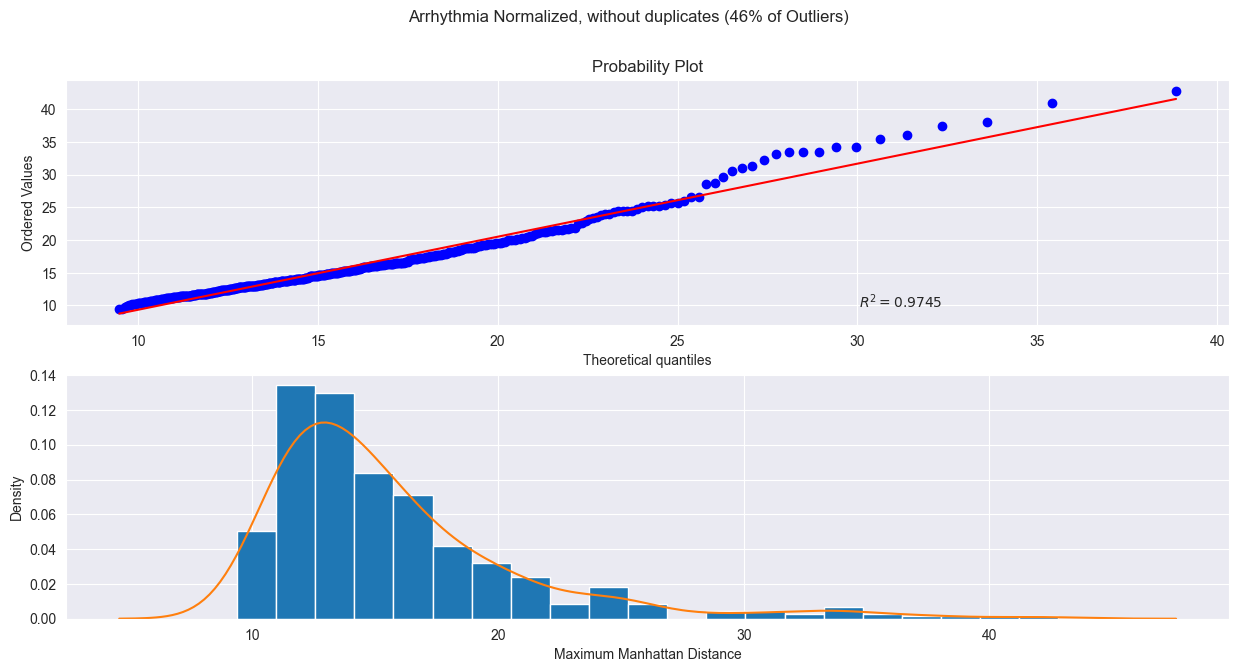

In [37]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,41,"Arrhythmia Normalized, without duplicates (46% of Outliers)")

0.7381660997732425 6 [0.6517148526077096, 0.6994047619047619, 0.733843537414966, 0.713860544217687, 0.7381660997732425, 0.6889172335600907, 0.6833191609977325, 0.6786422902494331, 0.6516439909297053, 0.6463293650793652, 0.6495890022675738, 0.6391014739229024, 0.6276218820861678, 0.6078514739229025, 0.6002692743764172, 0.5932539682539683, 0.5839002267573696, 0.5877976190476191, 0.5795068027210885, 0.576672335600907, 0.5779478458049887, 0.5728458049886621, 0.5709325396825397, 0.5645549886621315, 0.5645549886621315, 0.5589569160997733, 0.5601615646258502, 0.5583900226757369, 0.5558390022675737, 0.5530045351473922, 0.5520833333333334, 0.5540674603174602, 0.5567602040816326, 0.5553429705215419, 0.5527919501133787, 0.5527919501133788, 0.5496031746031746, 0.5532879818594104, 0.5506660997732427, 0.5454931972789115, 0.5454931972789115, 0.5440051020408163, 0.5400368480725624, 0.5319586167800454, 0.5386904761904762, 0.532312925170068, 0.5378401360544217, 0.5337301587301588, 0.5268565759637188, 0.

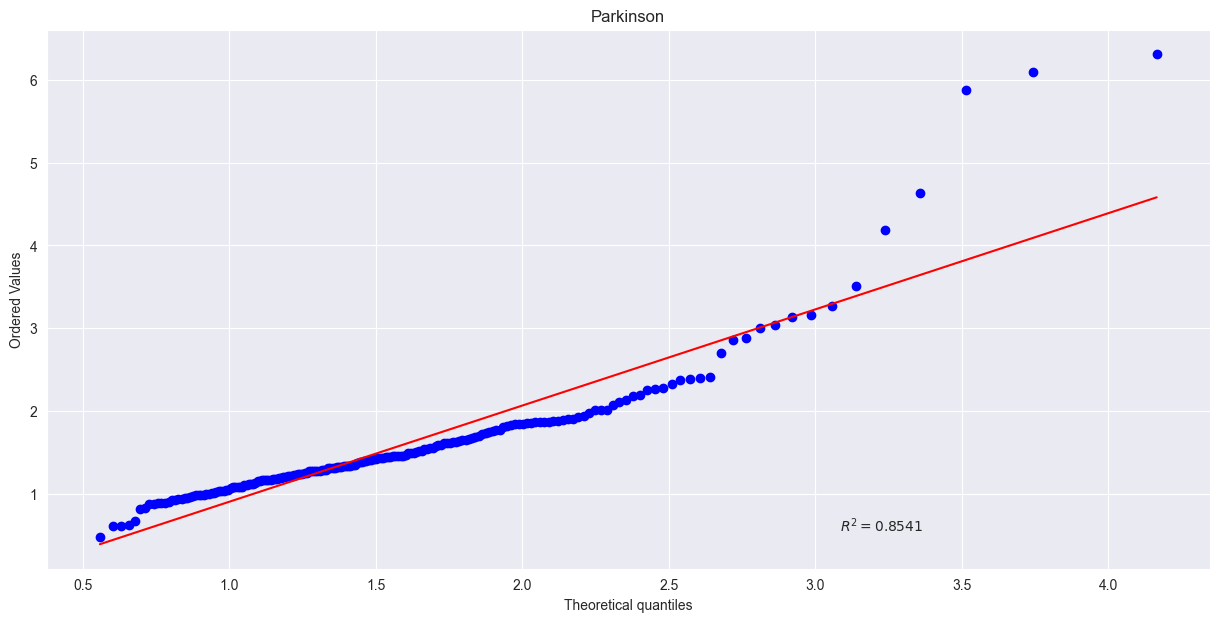

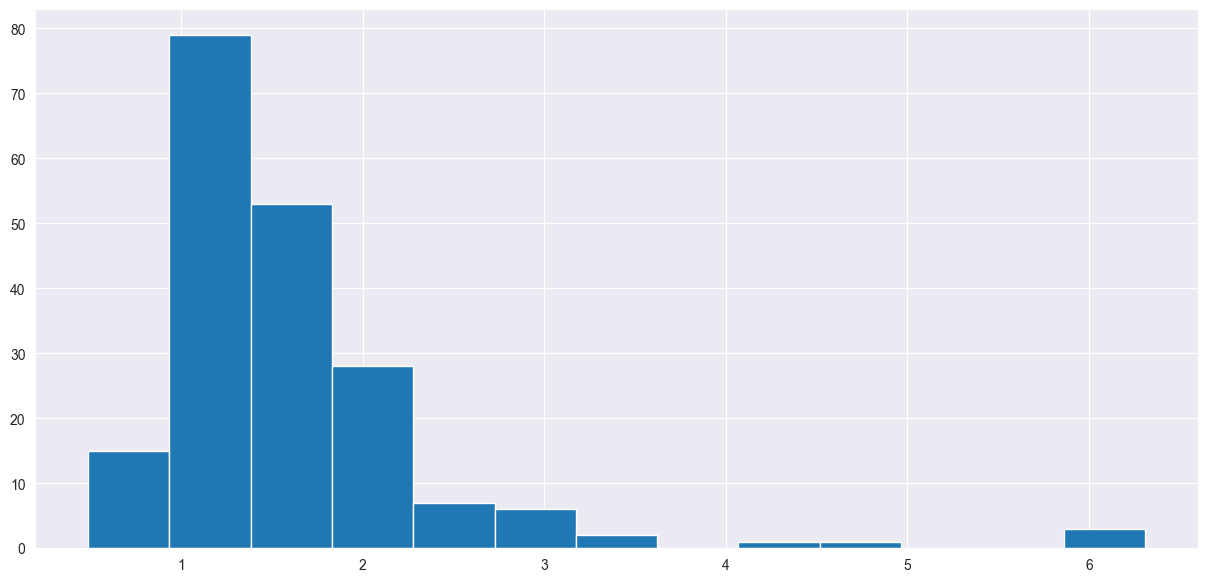

In [4]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,6,"Parkinson")

0.8201538461538461 5 [0.309, 0.45126923076923076, 0.5813846153846155, 0.8201538461538461, 0.8020384615384615, 0.7936538461538462, 0.8171153846153847, 0.7918076923076923, 0.8128846153846154, 0.7926538461538462, 0.7766923076923078, 0.7713461538461539, 0.7713461538461539, 0.7659615384615385, 0.7706538461538462, 0.7786153846153847, 0.7703846153846154, 0.7520384615384615, 0.7546538461538461, 0.7538076923076924, 0.756576923076923, 0.7506153846153847, 0.7447692307692307, 0.7444615384615384, 0.7412307692307694, 0.7317307692307693, 0.7437307692307693, 0.7316153846153847, 0.7563076923076922, 0.7355384615384615, 0.7349230769230769, 0.736576923076923, 0.7433076923076922, 0.7370769230769231, 0.7303076923076922, 0.7227692307692307, 0.7316153846153847, 0.7369999999999998, 0.7334615384615384, 0.738576923076923, 0.7259615384615384, 0.721346153846154, 0.7272307692307692, 0.7177307692307692, 0.7205769230769231, 0.7157692307692307, 0.7083846153846155, 0.711653846153846, 0.7047692307692308, 0.7018076923076

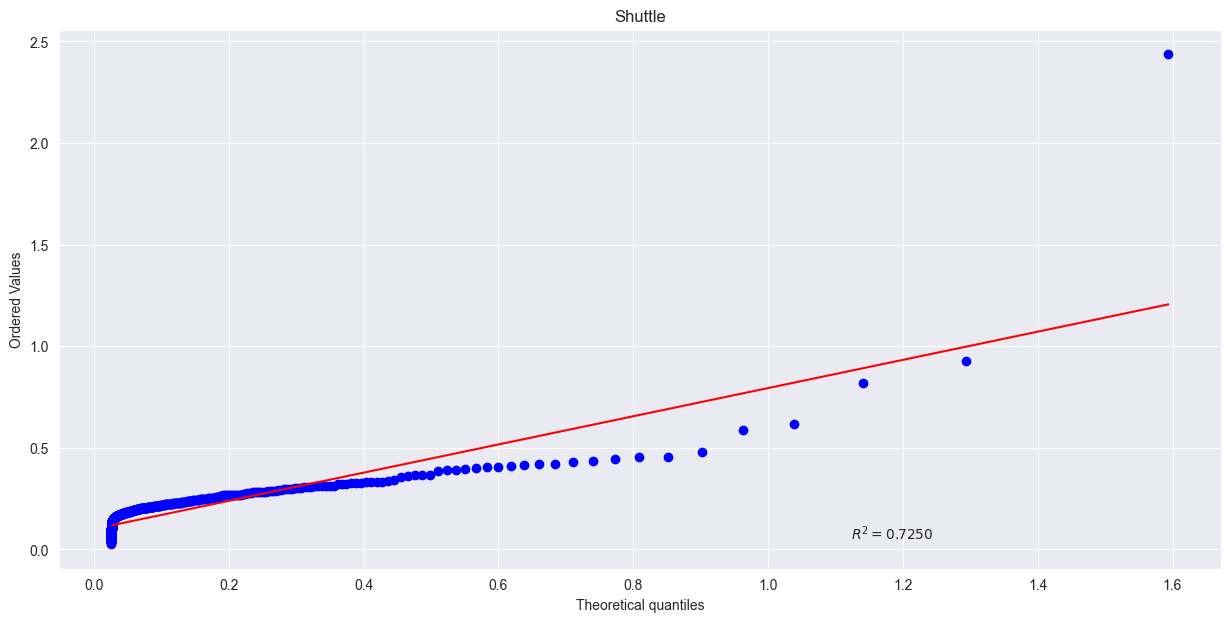

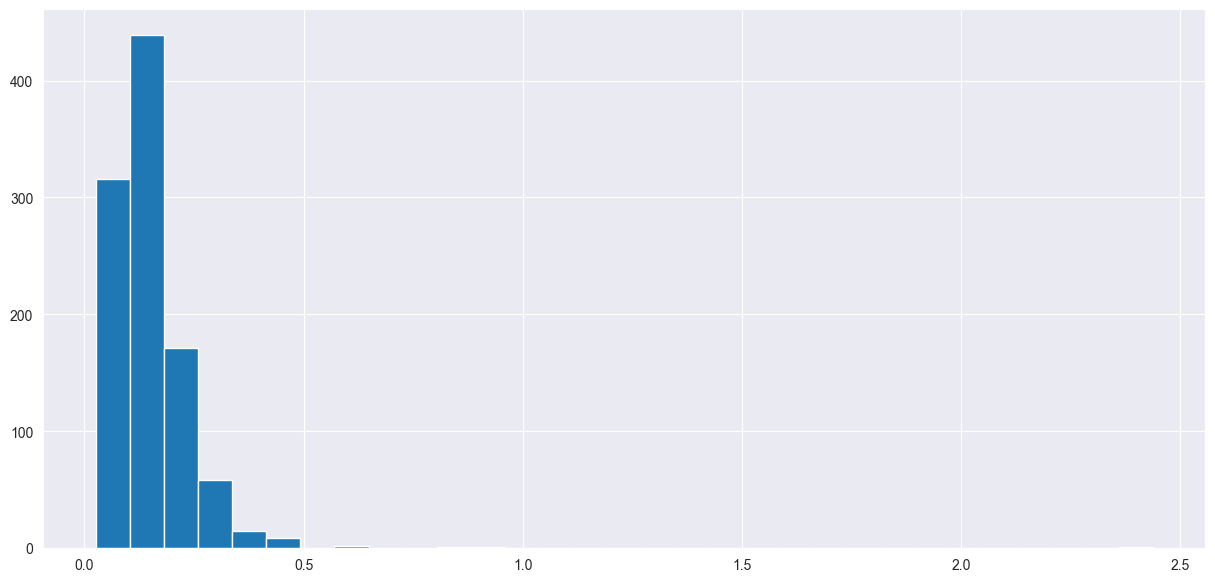

In [5]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,5,"Shuttle")

0.9985915492957746 40 [0.9680751173708921, 0.9366197183098591, 0.9826291079812207, 0.9943661971830986, 0.9906103286384976, 0.9906103286384976, 0.9896713615023476, 0.9929577464788735, 0.9948356807511737, 0.9957746478873238, 0.9936619718309859, 0.9889671361502348, 0.9929577464788732, 0.9887323943661972, 0.9922535211267606, 0.9901408450704225, 0.9929577464788732, 0.9946009389671361, 0.9906103286384975, 0.9887323943661971, 0.9969483568075117, 0.9969483568075117, 0.9981220657276995, 0.9981220657276996, 0.9974178403755869, 0.9976525821596244, 0.9981220657276996, 0.9974178403755869, 0.9967136150234742, 0.9967136150234741, 0.9967136150234741, 0.9967136150234742, 0.9967136150234741, 0.996244131455399, 0.9903755868544601, 0.9948356807511737, 0.9948356807511737, 0.9948356807511738, 0.9985915492957746, 0.9985915492957746, 0.9931924882629107, 0.9964788732394366, 0.9964788732394367, 0.9957746478873238, 0.9884976525821595, 0.9969483568075117, 0.995774647887324, 0.995774647887324, 0.9971830985915493, 

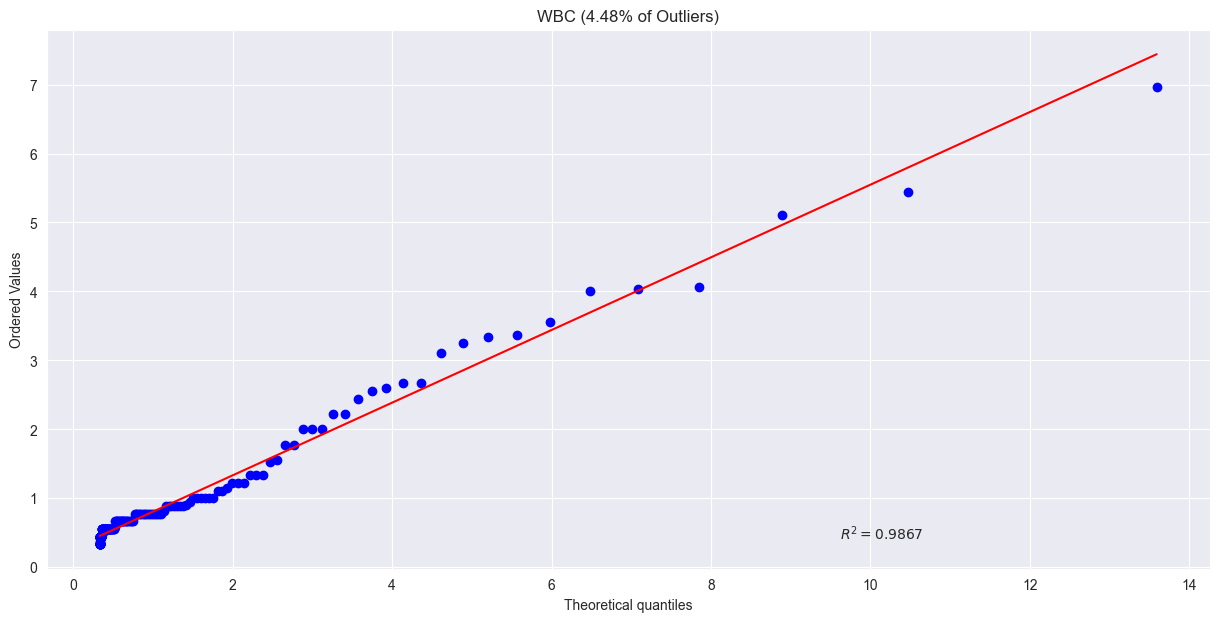

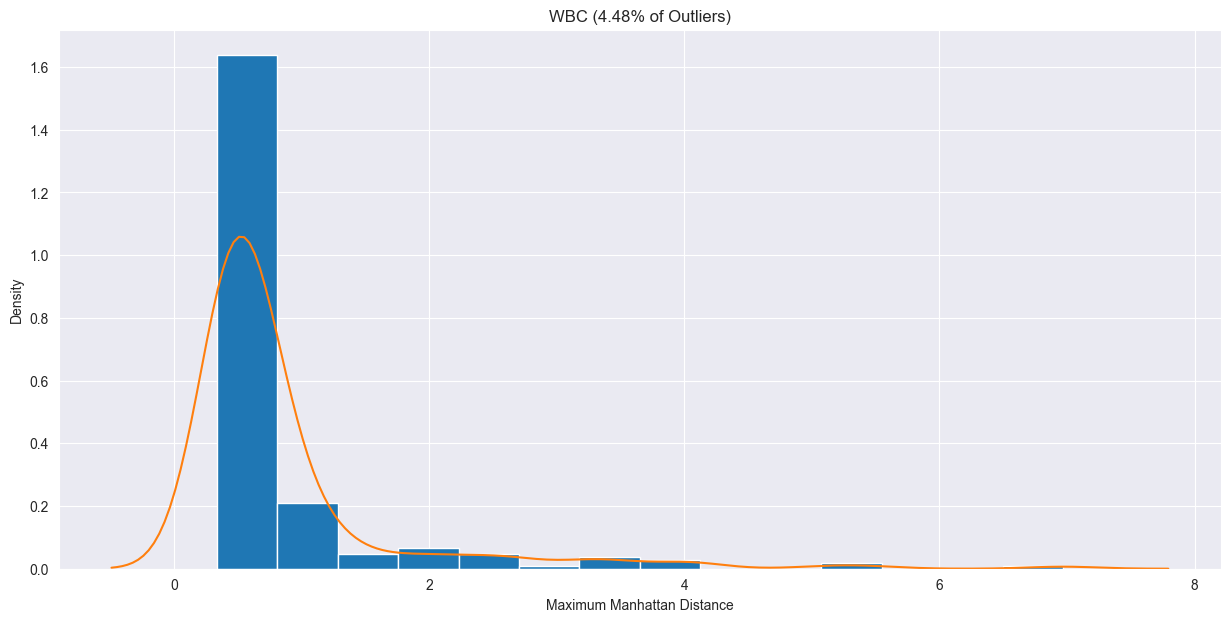

In [30]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,40,"WBC (4.48% of Outliers)")

0.6500094710534449 49 [0.40957040526684807, 0.47398464181512495, 0.5094399544635521, 0.5299946142218468, 0.5464403210545757, 0.5695386183382213, 0.5857480200315136, 0.591077490180261, 0.6071998382852963, 0.6177484007584382, 0.6217028011700757, 0.622922140401535, 0.6271144951410197, 0.6282162707986219, 0.6313299385182561, 0.6328667465187988, 0.6366137025881893, 0.6386444425177735, 0.6393690252259859, 0.6411918496166343, 0.641126706674407, 0.6419392853642539, 0.6450740391357124, 0.6473296576850295, 0.6475908184498005, 0.6475070632383653, 0.6471193861626495, 0.6463208255742947, 0.6463771335786067, 0.6453687726645608, 0.6459555303412972, 0.6463922118726487, 0.6467306488943841, 0.6467615122775009, 0.6465704420201898, 0.6463965704420201, 0.6481291606667622, 0.6487125021675048, 0.649830769709215, 0.6499806102562555, 0.6498671696534254, 0.649559596014807, 0.6495680775552053, 0.6488027363334112, 0.6492398890614516, 0.6487841240642035, 0.6488989782571, 0.6500094710534449, 0.6494996362361563, 0.6

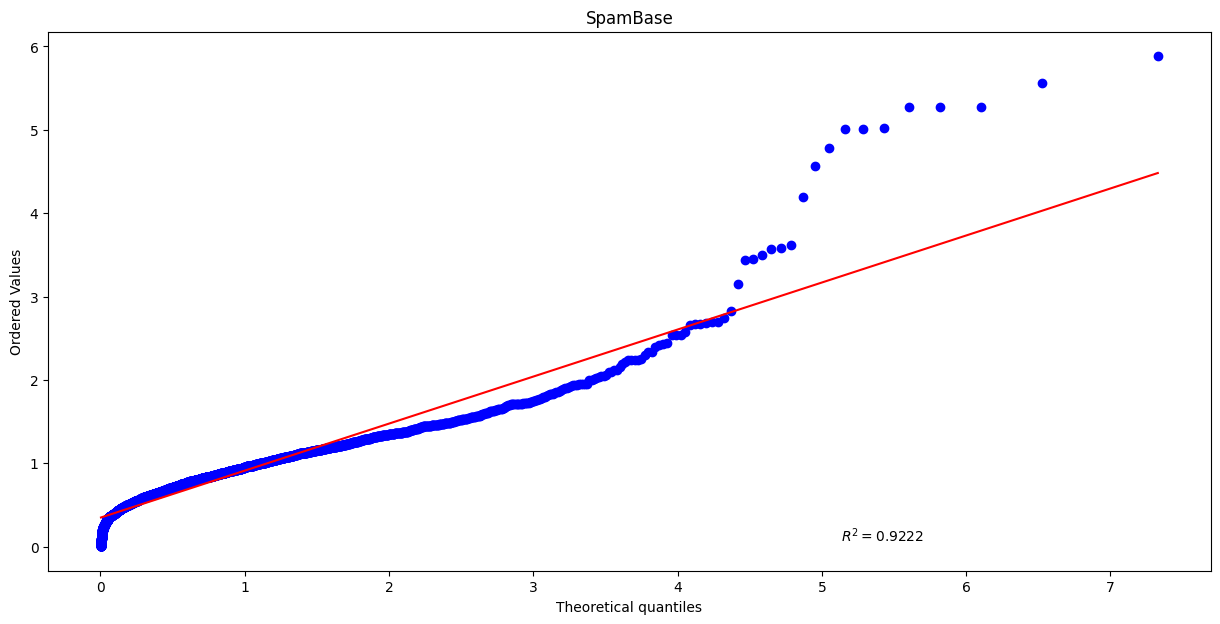

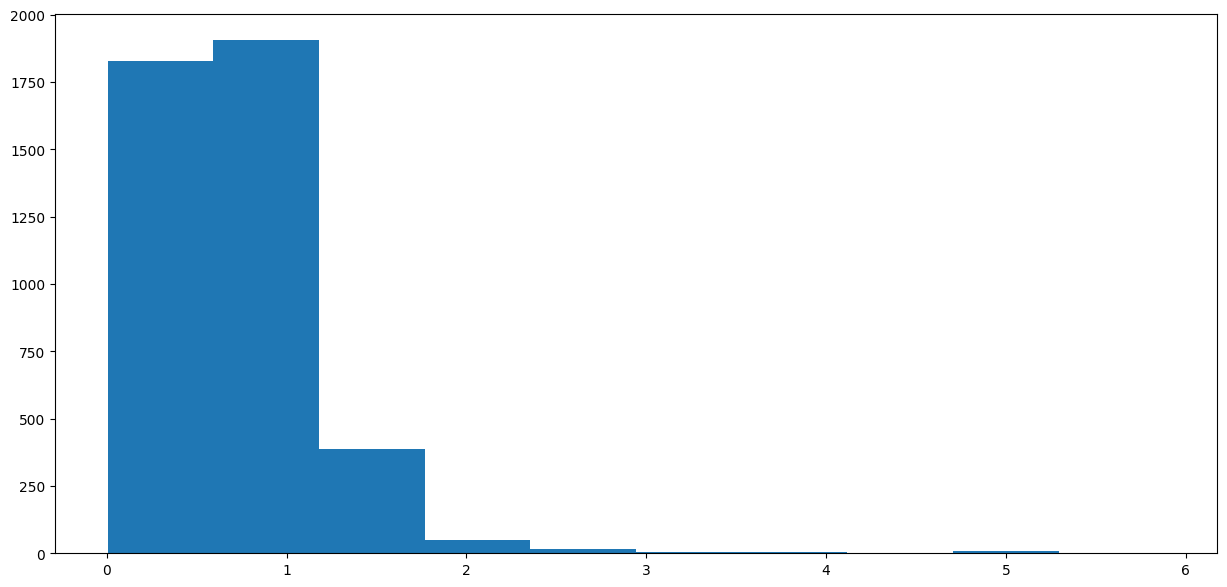

In [10]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,49,"SpamBase")

0.5315626320980695 26 [0.46322389742144565, 0.5043680428350007, 0.5207129773143582, 0.5201493588840355, 0.5212061434408906, 0.5191630266309708, 0.515006340707341, 0.5219811187825841, 0.5260673524024235, 0.5271241369592784, 0.5264196139213753, 0.5271241369592785, 0.5266309708327461, 0.5269127800479075, 0.5267718754403269, 0.5241651402000846, 0.5231083556432297, 0.5274059461744398, 0.5312808228829081, 0.5263491616175849, 0.5271945892630688, 0.5242355925038749, 0.522403832605326, 0.5267718754403267, 0.5315626320980695, 0.5221220233901647, 0.5202198111878258, 0.5247992109341975, 0.5233197125546004, 0.5188812174158095, 0.5223333803015359, 0.5187403128082289, 0.5205016204029872, 0.5157108637452444, 0.5115541778216147, 0.5121177962519374, 0.5119768916443567, 0.5142313653656474, 0.5139495561504861, 0.5132450331125828, 0.5102155840495984, 0.5143018176694377, 0.5129632238974214, 0.5114837255178244, 0.5112019163026632, 0.5083838241510498, 0.5055657319994364, 0.5069043257714527, 0.5045089474425815

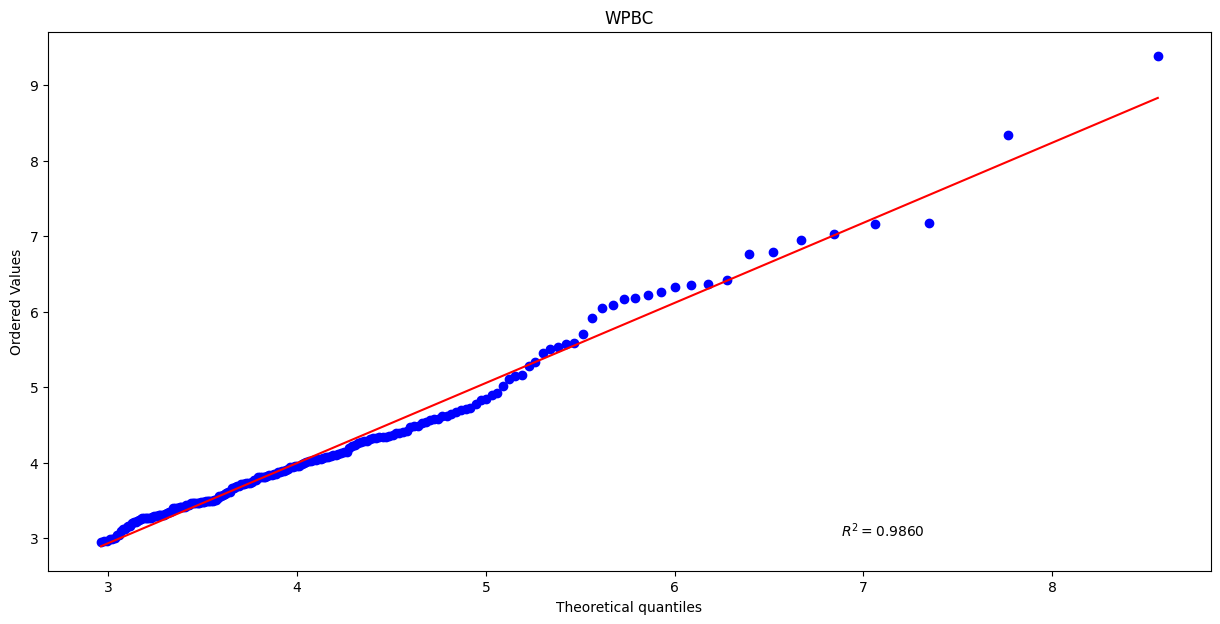

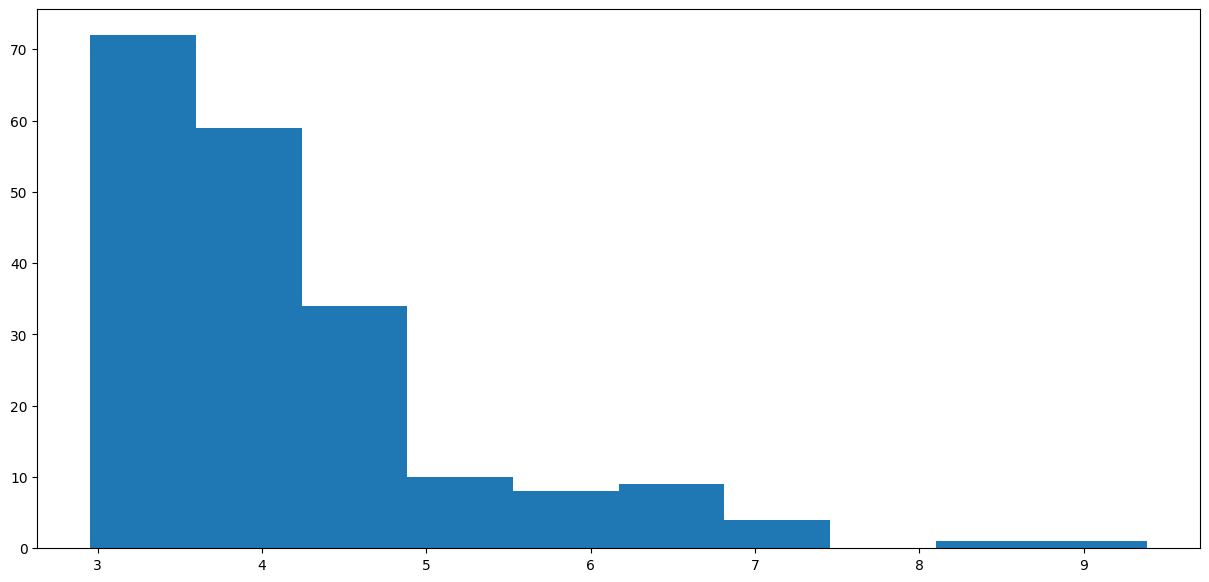

In [11]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"WPBC")

0.7001666666666667 66 [0.6128333333333335, 0.6227222222222223, 0.61825, 0.6211388888888887, 0.6220277777777778, 0.6295000000000001, 0.6333333333333334, 0.6383333333333333, 0.6458333333333335, 0.64325, 0.6478055555555555, 0.6542777777777777, 0.6528333333333335, 0.6615833333333335, 0.663, 0.6629722222222224, 0.6621388888888889, 0.6609444444444444, 0.6593055555555555, 0.6592499999999999, 0.6621388888888889, 0.663611111111111, 0.6590833333333335, 0.6555555555555557, 0.6653333333333333, 0.6640555555555556, 0.6604444444444445, 0.6619722222222223, 0.6618055555555556, 0.6609166666666667, 0.6613611111111111, 0.6584722222222222, 0.6621666666666666, 0.6635277777777776, 0.6611388888888888, 0.6620555555555556, 0.6632222222222222, 0.6651388888888888, 0.6656944444444444, 0.6680833333333334, 0.6683611111111112, 0.6684722222222224, 0.6703888888888889, 0.6700833333333335, 0.6728611111111111, 0.6734722222222224, 0.6750277777777778, 0.6755833333333333, 0.6792222222222224, 0.6781388888888888, 0.68083333333

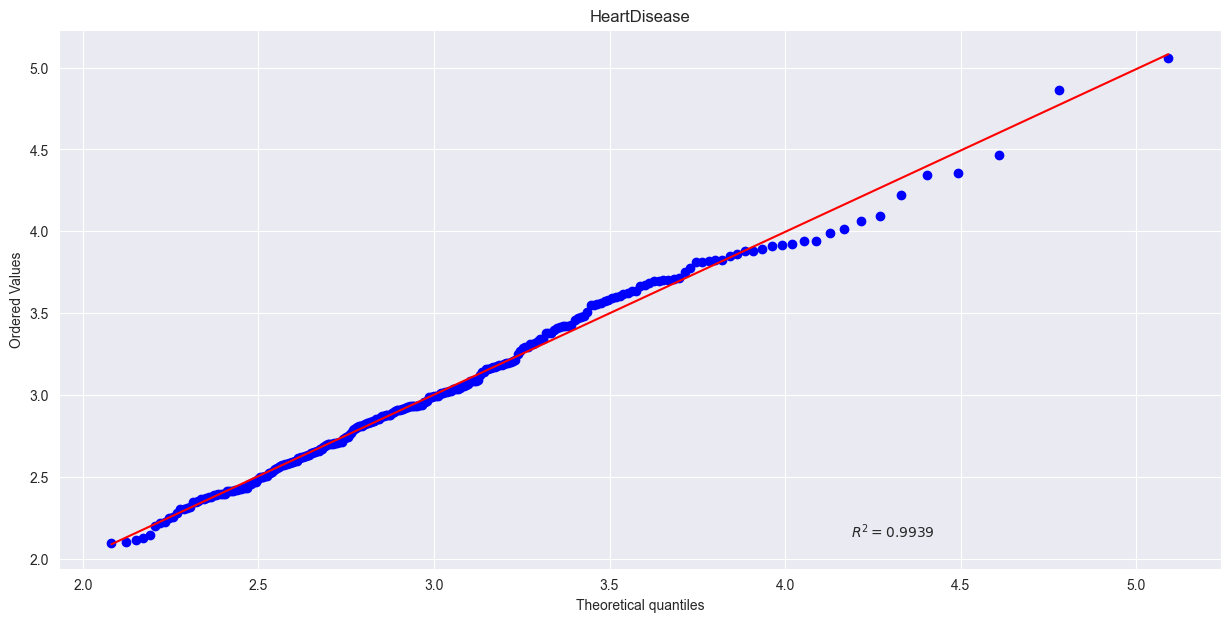

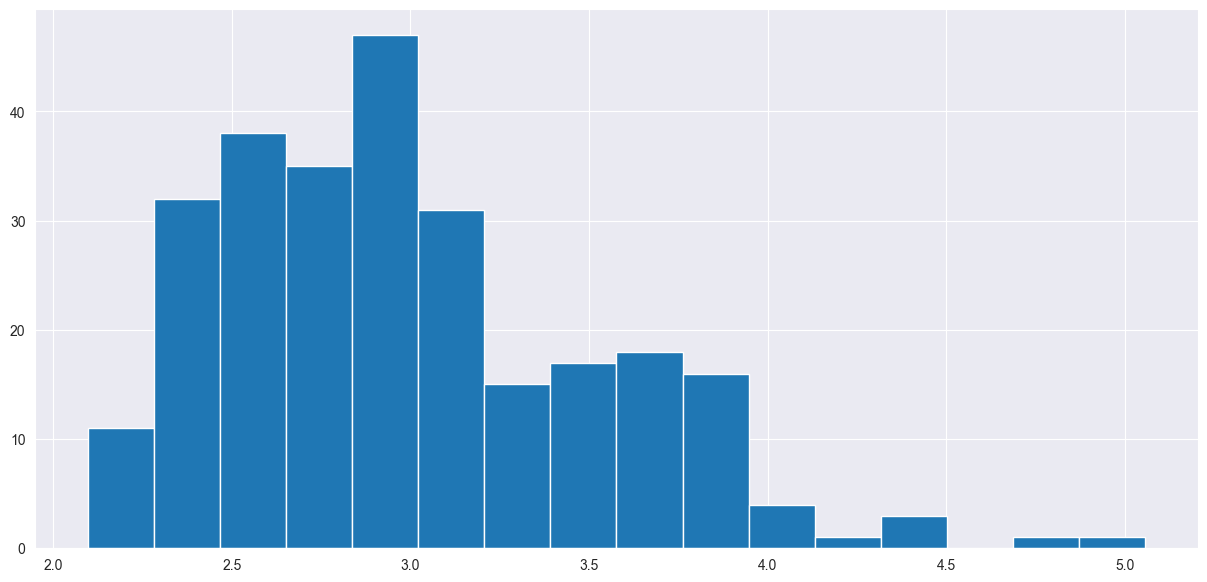

In [6]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,66,"HeartDisease")

0.8804878048780487 2 [0.8804878048780487, 0.8371273712737128, 0.8663956639566396, 0.8650406504065041, 0.862059620596206, 0.8612466124661247, 0.872628726287263, 0.8642276422764228, 0.8718157181571816, 0.8691056910569106, 0.8685636856368564, 0.8663956639566395, 0.8693766937669378, 0.8669376693766937, 0.865040650406504, 0.8588075880758808, 0.8658536585365855, 0.8574525745257453, 0.8601626016260162, 0.8672086720867208, 0.8558265582655826, 0.8276422764227642, 0.8227642276422765, 0.8075880758807588, 0.8046070460704606, 0.8010840108401085, 0.8032520325203251, 0.7850948509485094, 0.7970189701897019, 0.7848238482384823, 0.7872628726287262, 0.8018970189701897, 0.7739837398373984, 0.7750677506775068, 0.7829268292682927, 0.7823848238482385, 0.7823848238482385, 0.7704607046070461, 0.7807588075880759, 0.7856368563685637, 0.7872628726287263, 0.78130081300813, 0.7915989159891599, 0.7872628726287264, 0.7897018970189701, 0.7775067750677507, 0.7872628726287264, 0.7807588075880758, 0.7829268292682927, 0.7

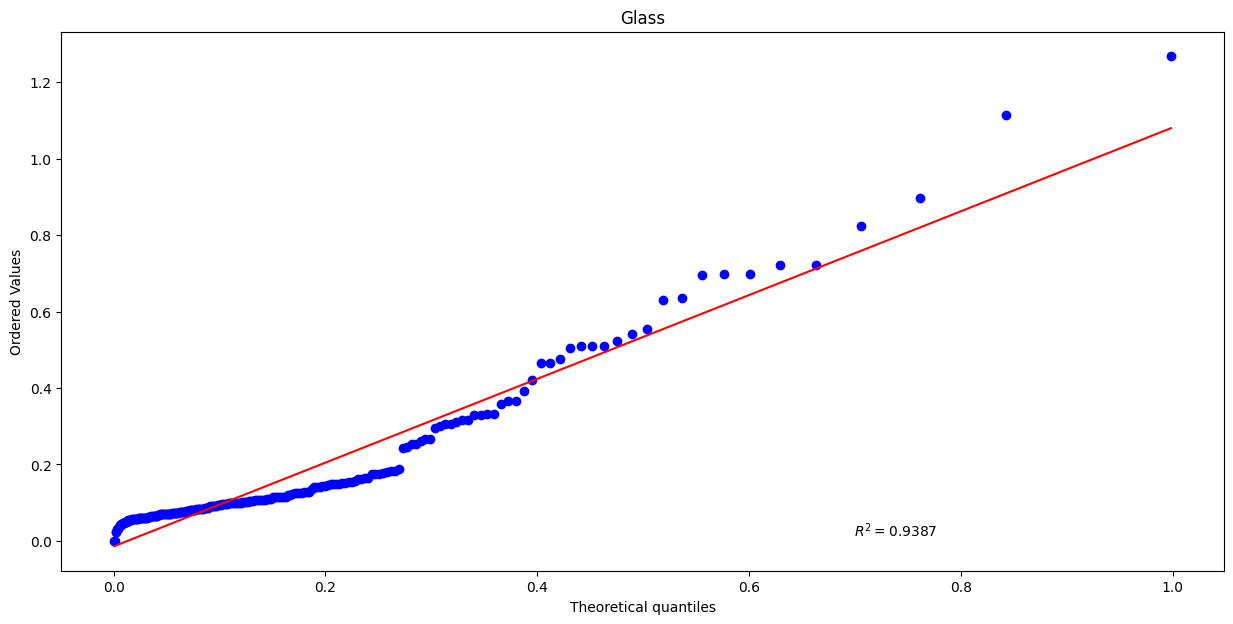

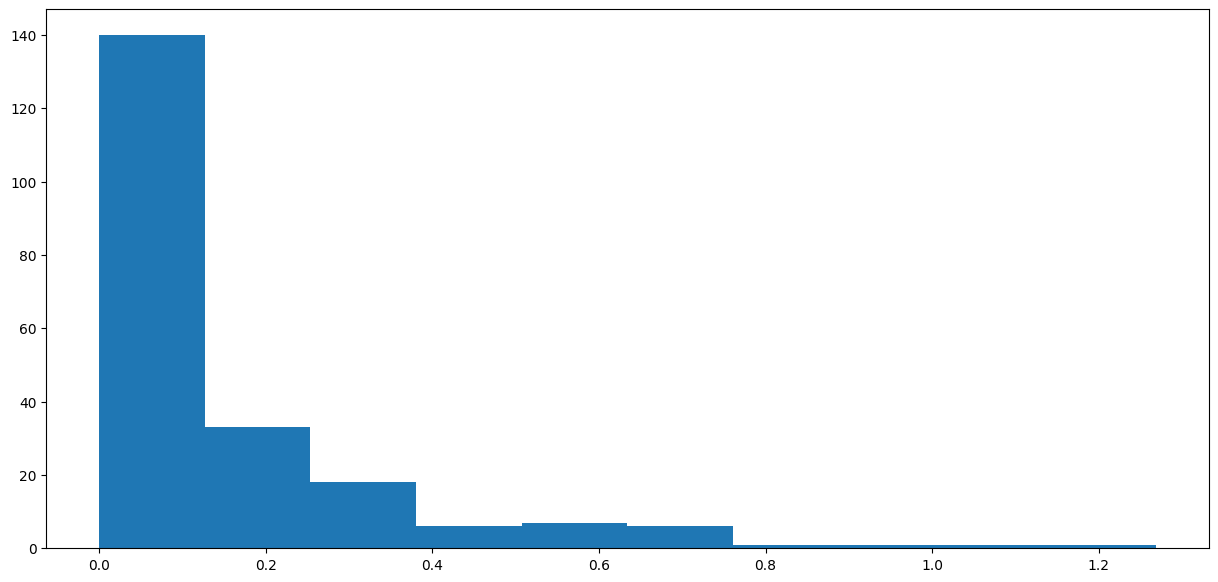

In [13]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,2,"Glass")

0.7847301951779564 26 [0.6222732491389208, 0.6153846153846154, 0.6509758897818599, 0.6681974741676234, 0.6647531572904707, 0.6710677382319175, 0.7032146957520092, 0.7146957520091849, 0.7072330654420207, 0.7146957520091847, 0.727324913892078, 0.7347876004592422, 0.7164179104477613, 0.7296211251435132, 0.7468427095292767, 0.7485648679678532, 0.7508610792192882, 0.7548794489092996, 0.7588978185993112, 0.769230769230769, 0.7692307692307693, 0.7698048220436279, 0.7726750861079218, 0.7830080367393799, 0.7847301951779564, 0.777841561423651, 0.7715269804822044, 0.7732491389207807, 0.7789896670493685, 0.7772675086107922, 0.7749712973593571, 0.7726750861079219, 0.7807118254879449, 0.7709529276693454, 0.7732491389207807, 0.7755453501722158, 0.7738231917336396, 0.7812858783008036, 0.7835820895522387, 0.7721010332950632, 0.7692307692307693, 0.756601607347876, 0.761768082663605, 0.7525832376578645, 0.7623421354764637, 0.7548794489092996, 0.7554535017221583, 0.7525832376578645, 0.74052812858783, 0.74

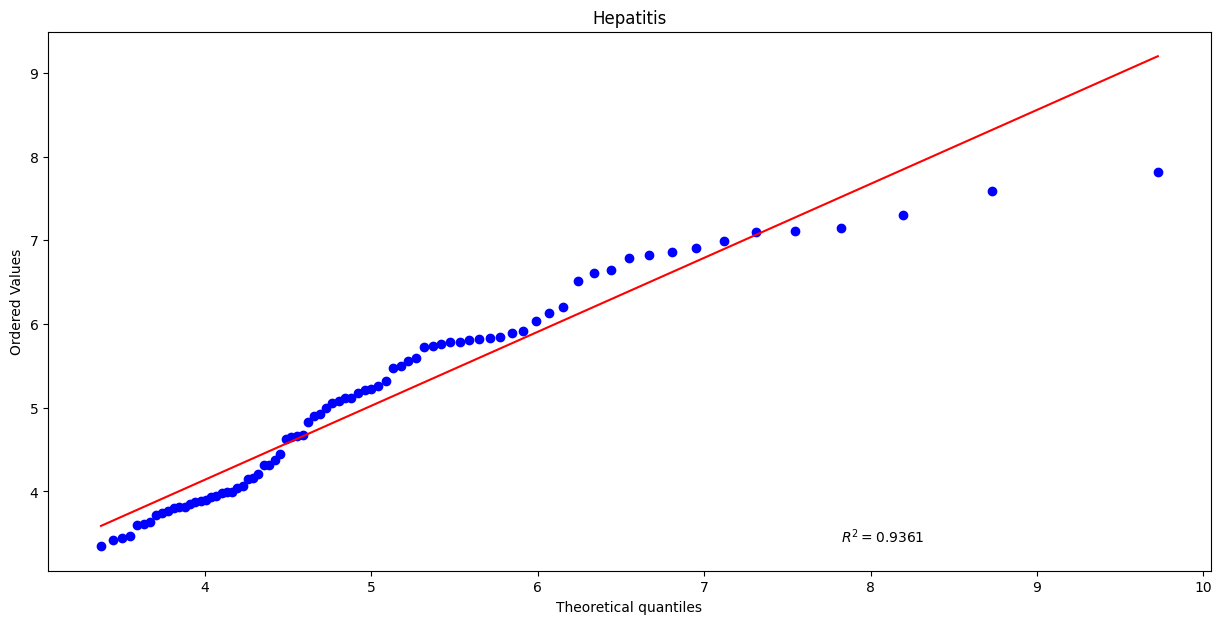

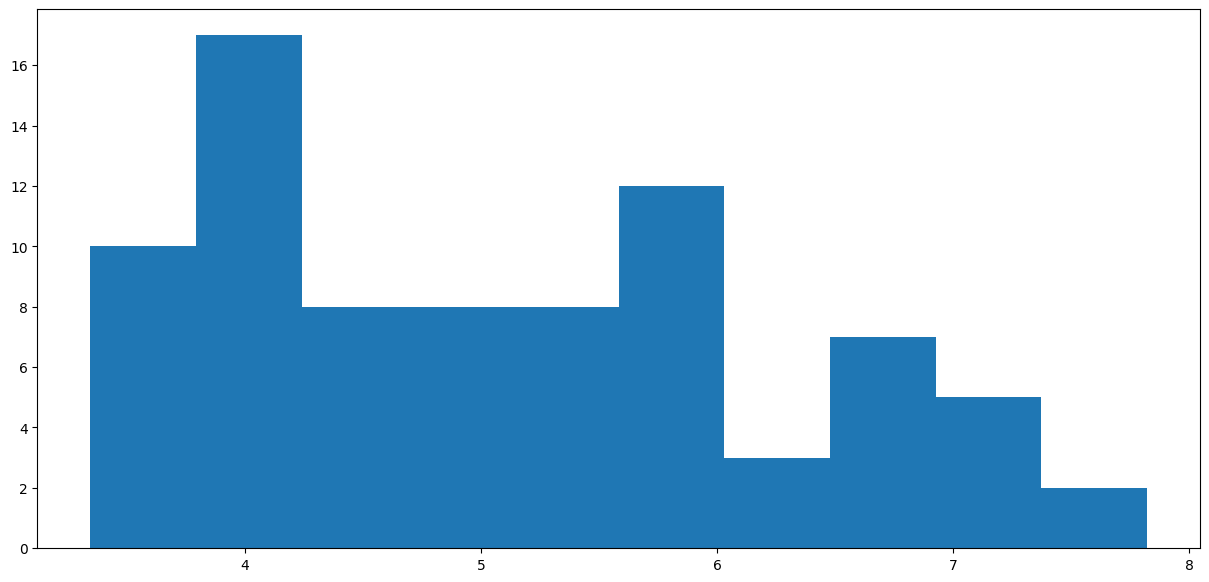

In [14]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"Hepatitis")

0.7359141791044777 69 [0.6767089552238807, 0.6914589552238807, 0.7063768656716417, 0.7087649253731343, 0.7118320895522388, 0.7153656716417911, 0.7181977611940299, 0.7204141791044777, 0.7210335820895521, 0.72069776119403, 0.720526119402985, 0.7221567164179106, 0.7221977611940299, 0.7222574626865672, 0.7224253731343284, 0.7217798507462688, 0.7228470149253733, 0.7235447761194029, 0.7238097014925374, 0.7258731343283582, 0.7261791044776119, 0.7288320895522389, 0.7271119402985076, 0.726973880597015, 0.7273544776119403, 0.7269104477611941, 0.7271007462686567, 0.7264365671641791, 0.7273470149253732, 0.7273320895522387, 0.728973880597015, 0.7293171641791045, 0.7288917910447762, 0.7285746268656716, 0.7287126865671644, 0.7284067164179105, 0.7288432835820895, 0.7290559701492537, 0.7289925373134328, 0.7294888059701492, 0.7304029850746268, 0.728455223880597, 0.7303768656716418, 0.7300970149253732, 0.7301082089552238, 0.7305671641791044, 0.7315223880597015, 0.7314141791044777, 0.7324179104477612, 0.7

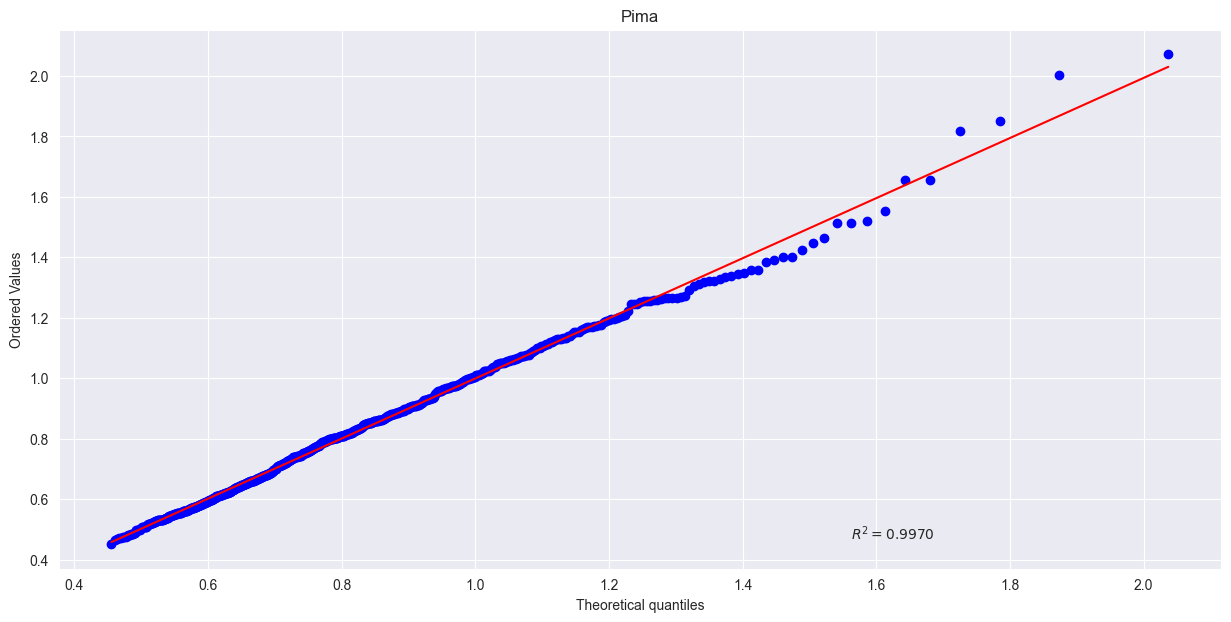

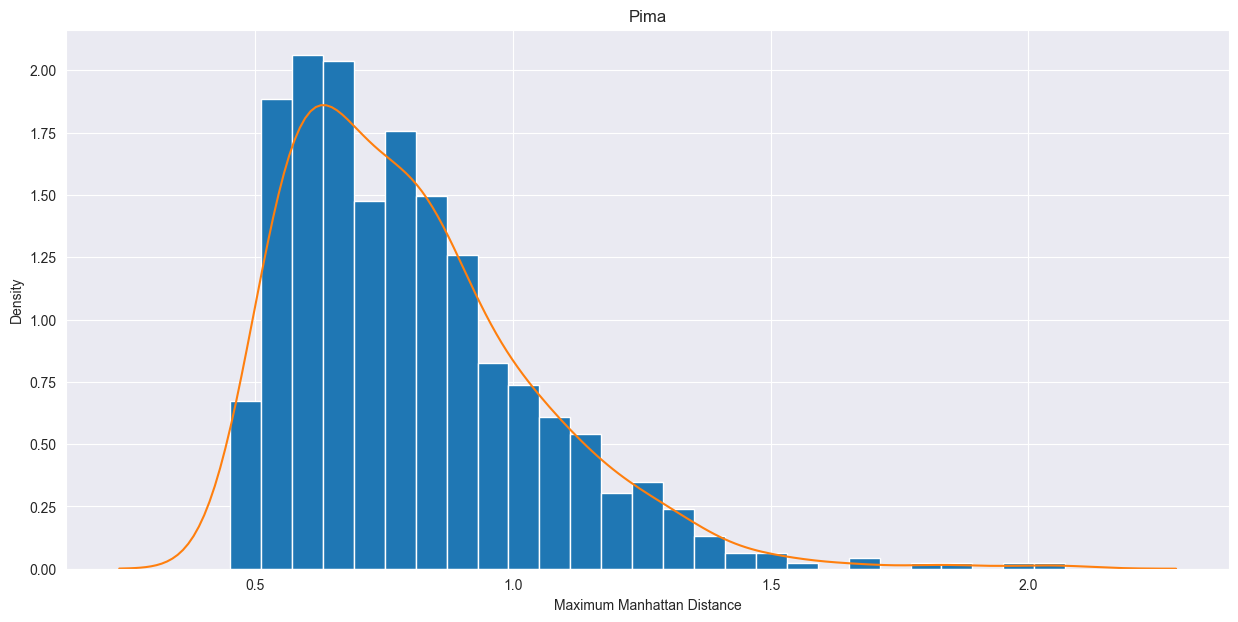

In [31]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,69,"Pima")

0.9826056051990251 12 [0.9270105605199025, 0.9720653939886271, 0.9737408610885459, 0.9770613322502032, 0.9773811941510968, 0.979102355808286, 0.9817374086108855, 0.9823009748172218, 0.9824735987002438, 0.9820928107229894, 0.9826056051990251, 0.982580219333875, 0.9823517465475222, 0.9807270511779042, 0.9808489033306256, 0.9805848903330625, 0.9805442729488222, 0.9809402924451667, 0.9801380991064176, 0.979538992688871, 0.979376523151909, 0.979813160032494, 0.9788688058489033, 0.9771044882209586, 0.9774446588139724, 0.9771222583265637, 0.9765967709179528, 0.9762261372867588, 0.9765231519090171, 0.9761525182778229, 0.976160134037368, 0.9766373883021932, 0.9765764622258326, 0.9759468927701057, 0.9759316612510155, 0.9761499796913078, 0.9763175264012998, 0.9743348903330625, 0.9747918359057677, 0.9751345450852965, 0.9747867587327375, 0.9747258326563769, 0.9743298131600325, 0.9743399675060925, 0.9747359870024371, 0.9743856620633632, 0.9737611697806661, 0.9735809301380992, 0.9731899878147846, 0.9

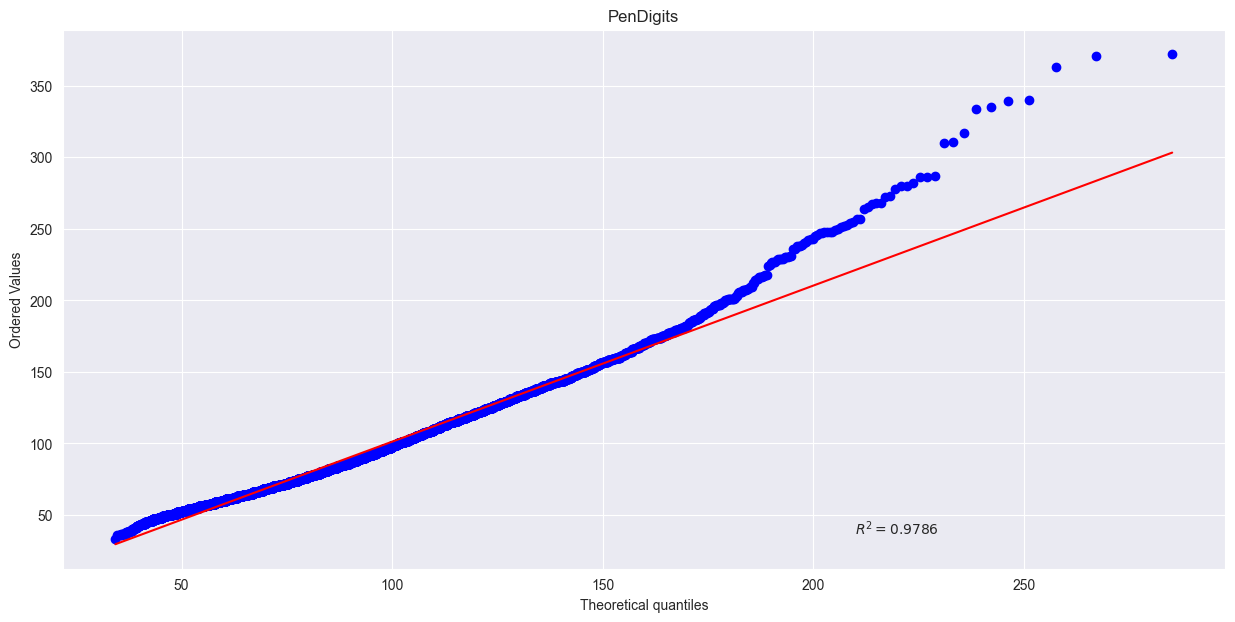

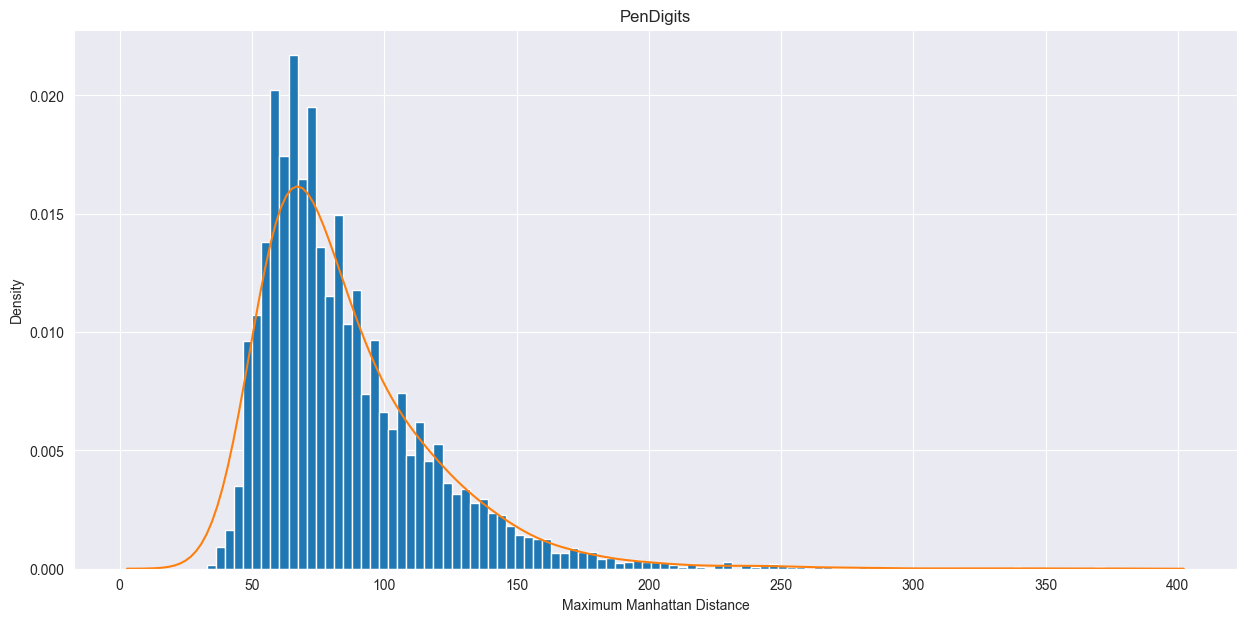

In [32]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,12,"PenDigits")

In [32]:
X, y = setupDf("clusters/artificial/cluto-t4-8k.arff")
endResults = outputResultsArt(X, y,checkValue=6)
printResults(endResults)

1.0 3 [0.9558823529411765, 1.0, 0.6287668236877525, 0.7454650486541226, 0.6752398433212858, 0.7570621468926552, 0.6851351351351351, 0.8931791646523337, 0.7801321245344015, 0.7575478927203064, 0.7667042042042043, 0.778688524590164, 0.6979695431472079, 0.8706896551724139, 0.9798850574712644, 0.8209325396825397, 0.9453188684053494, 0.8311676753292987, 0.8163638508730533, 0.8324501424501425, 0.4442567567567568, 0.7976664378860672, 1.0, 0.7940467123635441, 0.9632443046127365, 0.9650092155906109, 0.9311735022864277, 1.0, 0.9301421468778063, 0.962889985330565, 0.795957284515637, 0.978494623655914, 0.7965423728813558, 1.0, 1.0, 1.0, 0.796094299788881, 1.0, 1.0, 1.0, 0.8166458483991846, 0.7920288390270198, 0.7810697808535177, 0.7725237091675448, 0.7706214689265536, 0.7807167235494881, 0.7756019109786669, 0.7781939117929051, 0.7948680860911824, 0.8044527434645217, 0.7912041505791506, 0.7816847722508099, 0.7763842437755479, 0.769245283018868, 0.783881237006237, 0.7820407648135294, 0.7777706227059

In [33]:
X, y = setupDf("clusters/artificial/cluto-t7-10k.arff")
endResults = outputResultsArt(X, y,checkValue=9)
printResults(endResults)

1.0 31 [0.8030024509803922, 0.6821496193046771, 0.7261256589750237, 0.8534055754516139, 0.7234396914446003, 0.888785798780519, 0.7825266336716717, 0.7568166737045304, 0.7774125132555675, 0.6060171919770774, 0.8329432971759274, 0.8775337837837838, 0.868182567144505, 0.7807486631016043, 0.8758066778900112, 0.8653776978417266, 0.8613281249999998, 0.84955446305116, 0.8574723247232473, 0.8534337702993545, 0.8350406436629065, 0.844293114973262, 0.834537197231834, 0.8594816947758125, 0.857652752571083, 0.8674254831313462, 0.8557968899820736, 0.868534304394604, 0.8688039354650435, 1.0, 0.8574512012012012, 0.8543378325508607, 1.0, 0.8607517482517483, 0.8644668158090976, 0.85596012679346, 0.8617906897723412, 0.9453238359055534, 0.9544160395014533, 0.0, 0.0, 0.0, 0.8355026505111702, 0.857238000095143, 0.0, 0.0, 0.8592156862745098, 0.8565672844480258, 0.8426772867420348, 0.8276436964115592, 0.8368671679197994, 0.8515166340508805, 0.8607962213225371, 0.8404710448551143, 0.8366203703703705, 0.843760

In [34]:
X, y = setupDf("clusters/artificial/cluto-t8-8k.arff")
endResults = outputResultsArt(X, y,checkValue=8)
printResults(endResults)

0.9299665528359885 46 [0.8222602739726027, 0.6079582085861398, 0.7765905269058295, 0.8053842683110244, 0.7144289725517153, 0.8031623931623932, 0.7480359147025815, 0.0, 0.0, 0.7465808297567955, 0.9144713013972817, 0.7137345679012348, 0.7062567713976164, 0.6799673485066742, 0.6751800330992531, 0.6648015202702704, 0.6718540268456377, 0.7413677307206068, 0.6896596374398816, 0.6956362033499853, 0.6682230156550399, 0.673754821398625, 0.6669526734104045, 0.6849887263687344, 0.6851048233396861, 0.6673371476250074, 0.6809722222222222, 0.6628763089005235, 0.7650933546247389, 0.68126582278481, 0.6790465930514409, 0.672847935328818, 0.6699451303155005, 0.6858711733242289, 0.6664463356192678, 0.6806927150422214, 0.6805826558265583, 0.6541135263762999, 0.6739932748298204, 0.6851945073691864, 0.6856609128822984, 0.6631143975641587, 0.674825174825175, 0.6703762187633158, 0.9299665528359885, 0.694953136265321, 0.6983900226757369, 0.7038370126605419, 0.711952861952862, 0.7022209821428572, 0.715396287825